<a href="https://colab.research.google.com/github/emadyowakim/AI-ML/blob/master/Churn_Prediction_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction — End-to-End ML Pipeline

A full applied ML workflow: data cleaning → EDA → feature engineering → model training/selection → evaluation → a lightweight inference function.

**Business problem:** An e-commerce/DTH provider wants to predict which customer accounts are at risk of churning so it can target retention offers before losing the account.

> **Data note:** This notebook expects `Customer Churn Data.xlsx` (a licensed Great Learning case-study dataset). Upload it when prompted in the cell below — it is **not** bundled with this notebook and should not be redistributed publicly.


## Detailed Business Context for Customer Churn Prediction

In today's highly competitive e-commerce and Direct-to-Home (DTH) service landscape, customer retention is paramount. Acquiring new customers is significantly more expensive than retaining existing ones. Our client, a prominent player in this sector, is facing the critical challenge of customer churn, which directly impacts their revenue, market share, and long-term sustainability.

**The Core Problem:** Customers discontinuing their services or subscriptions. This results in lost recurring revenue, increased customer acquisition costs, and a potential negative impact on brand reputation through word-ofmouth.

**Objective:** To develop a robust Machine Learning pipeline that can accurately predict which customers are at high risk of churning. This proactive identification is crucial for the Customer Relationship Management (CRM) department to intervene with targeted retention strategies before the customer is lost.

**Strategic Importance:**
*   **Revenue Protection:** Early identification of at-risk customers allows for personalized offers, discounts, or service improvements, directly mitigating revenue loss.
*   **Optimized Resource Allocation:** Instead of blanket retention campaigns, the CRM team can focus its efforts and resources on the most vulnerable and valuable customers.
*   **Improved Customer Lifetime Value (CLTV):** By extending customer tenure, we directly increase their CLTV, fostering long-term profitability.
*   **Enhanced Customer Satisfaction:** Proactive engagement based on predictive insights can lead to improved customer experience and loyalty.

This project aims to build an end-to-end solution, from raw data to a deployable model, providing actionable insights to safeguard the customer base and drive business growth.

## Churn Categories for Targeted Interventions

To enable the customer relationship department to implement differentiated retention strategies, we will categorize potential churners into distinct risk bands. These categories are based on the urgency and predicted timeframe of churn:

1.  **Immediate Churn Risk (High Probability):** Customers with a very high probability of churning in the very near future (e.g., next 1-2 months). These require immediate, high-priority intervention.
2.  **Short-Term Churn Risk (Within 3 Months):** Customers likely to churn within the next three months. These warrant targeted offers or proactive support to address potential pain points.
3.  **Mid-Term Churn Risk (Within 6 Months):** Customers showing signs of potential churn within the next six months. Regular check-ins, loyalty programs, or engagement initiatives might be suitable here.
4.  **Long-Term Churn Risk (Beyond 6 Months):** Customers exhibiting subtle indicators that could lead to churn in the distant future. This group can be monitored, and general customer experience improvements can help mitigate risk over time.

## 1. Setup

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn openpyxl catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay,
)
import joblib
import json

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load Data

Run the cell below and upload `Customer Churn Data.xlsx` when prompted (works in Google Colab via `google.colab.files`). If running outside Colab, just set `DATA_PATH` to a local file path instead.

In [3]:
try:
    from google.colab import files
    uploaded = files.upload()  # select "Customer Churn Data.xlsx"
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    # Not running in Colab — set the path manually
    DATA_PATH = "Customer Churn Data.xlsx"

df_raw = pd.read_excel(DATA_PATH, sheet_name="Data for DSBA")
print("Shape:", df_raw.shape)
df_raw.head()

Saving Customer Churn Data.xlsx to Customer Churn Data.xlsx
Shape: (11260, 19)


,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

In [5]:
print("Missing values per column:")
df_raw.isnull().sum().sort_values(ascending=False)

Missing values per column:


,0
cashback,471
Complain_ly,357
Day_Since_CC_connect,357
Login_device,221
Marital_Status,212
CC_Agent_Score,116
Account_user_count,112
City_Tier,112
Payment,109
Gender,108


In [6]:
print("Churn rate (raw):")
df_raw["Churn"].value_counts(normalize=True)

Churn rate (raw):


,proportion
Churn,
0,0.831616
1,0.168384


## 3. Data Quality Investigation

Before cleaning, let's check the categorical columns for inconsistent labels or garbage placeholder values — a common real-world data issue.

In [7]:
cat_cols = ["Payment", "Gender", "account_segment", "Marital_Status", "Login_device"]
for c in cat_cols:
    print(c, "->", df_raw[c].unique())

Payment -> ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet' nan]
Gender -> ['Female' 'Male' 'F' nan 'M']
account_segment -> ['Super' 'Regular Plus' 'Regular' 'HNI' 'Regular +' nan 'Super Plus'
 'Super +']
Marital_Status -> ['Single' 'Divorced' 'Married' nan]
Login_device -> ['Mobile' 'Computer' '&&&&' nan]


In [8]:
# Numeric-looking columns stored as strings often hide junk tokens
print("Tenure unique sample:", df_raw["Tenure"].unique()[:15])
print("rev_per_month unique sample:", df_raw["rev_per_month"].unique()[:15])

Tenure unique sample: [4 0 2 13 11 '#' 9 99 19 20 14 8 26 18 5]
rev_per_month unique sample: [9 7 6 8 3 2 4 10 1 5 '+' 130 nan 19 139]


**Findings:**
- `Gender` mixes `'F'`/`'Male'` style aliases with `'Female'`/`'Male'`.
- `account_segment` has inconsistent variants: `'Regular +'` vs `'Regular Plus'`, `'Super +'` vs `'Super Plus'`.
- `Login_device` contains a garbage token `'&&&&'`.
- `Tenure` (and likely other "numeric" columns) contains a `'#'` placeholder, which silently breaks numeric dtype inference and hides missingness.

## 4. Data Cleaning

In [9]:
NUMERIC_COLS = [
    "Tenure", "City_Tier", "CC_Contacted_LY", "Service_Score",
    "Account_user_count", "CC_Agent_Score", "rev_per_month", "Complain_ly",
    "rev_growth_yoy", "coupon_used_for_payment", "Day_Since_CC_connect", "cashback",
]
CATEGORICAL_COLS = ["Payment", "Gender", "account_segment", "Marital_Status", "Login_device"]

GENDER_MAP = {"F": "Female", "M": "Male", "Female": "Female", "Male": "Male"}
SEGMENT_MAP = {
    "Regular +": "Regular Plus", "Regular Plus": "Regular Plus", "Regular": "Regular",
    "Super +": "Super Plus", "Super Plus": "Super Plus", "Super": "Super", "HNI": "HNI",
}
GARBAGE_TOKENS = ["&&&&", "#", "*", "?", ""]


def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Replace garbage tokens with NaN across all columns
    df = df.replace(GARBAGE_TOKENS, np.nan)

    # Coerce numeric columns (junk tokens become NaN automatically)
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Normalise categorical labels
    df["Gender"] = df["Gender"].map(GENDER_MAP).fillna(df["Gender"])
    df["account_segment"] = df["account_segment"].map(SEGMENT_MAP).fillna(df["account_segment"])
    for col in CATEGORICAL_COLS:
        # Plain object dtype (not pandas 'string' dtype) so sklearn imputers/encoders work correctly
        df[col] = df[col].astype(object).where(df[col].notna(), np.nan)
        df[col] = df[col].apply(lambda v: v.strip() if isinstance(v, str) else v)

    df = df.drop_duplicates(subset="AccountID")
    return df


df = clean(df_raw)
print("Cleaned shape:", df.shape)
df.isnull().sum().sort_values(ascending=False)

Cleaned shape: (11260, 19)


/tmp/ipykernel_1761/965459564.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(GARBAGE_TOKENS, np.nan)


,0
rev_per_month,791
Login_device,760
cashback,473
Account_user_count,444
Day_Since_CC_connect,358
Complain_ly,357
Tenure,218
Marital_Status,212
CC_Agent_Score,116
City_Tier,112


In [10]:
# Confirm fixes
print(df["Gender"].unique())
print(df["account_segment"].unique())
print(df["Login_device"].unique())

['Female' 'Male' nan]
['Super' 'Regular Plus' 'Regular' 'HNI' nan 'Super Plus']
['Mobile' 'Computer' nan]


## 5. Exploratory Data Analysis

Overall churn rate: 16.8%


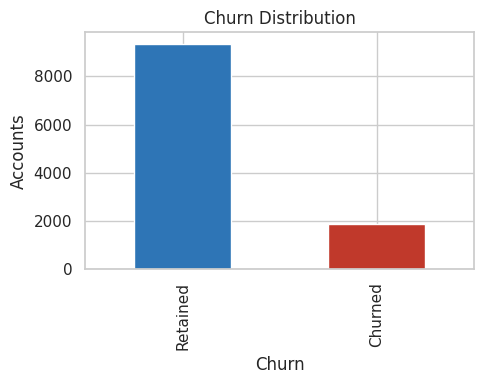

In [11]:
churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

plt.figure(figsize=(5, 4))
df["Churn"].value_counts().rename({0: "Retained", 1: "Churned"}).plot(
    kind="bar", color=["#2E75B6", "#C0392B"]
)
plt.title("Churn Distribution")
plt.ylabel("Accounts")
plt.tight_layout()
plt.show()

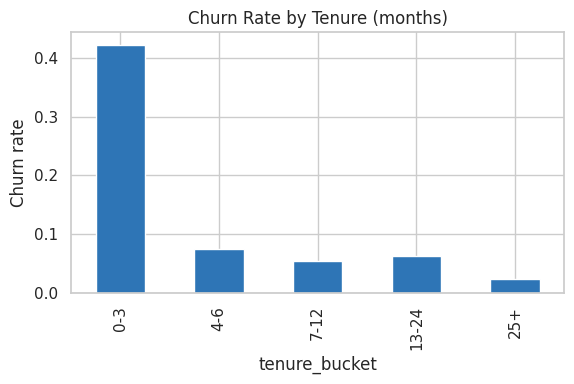

tenure_bucket
0-3      0.422594
4-6      0.075278
7-12     0.053869
13-24    0.062048
25+      0.024242
Name: Churn, dtype: float64


In [12]:
df["tenure_bucket"] = pd.cut(
    df["Tenure"], bins=[-1, 3, 6, 12, 24, 100], labels=["0-3", "4-6", "7-12", "13-24", "25+"]
)
tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].mean()

plt.figure(figsize=(6, 4))
tenure_churn.plot(kind="bar", color="#2E75B6")
plt.title("Churn Rate by Tenure (months)")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

print(tenure_churn)

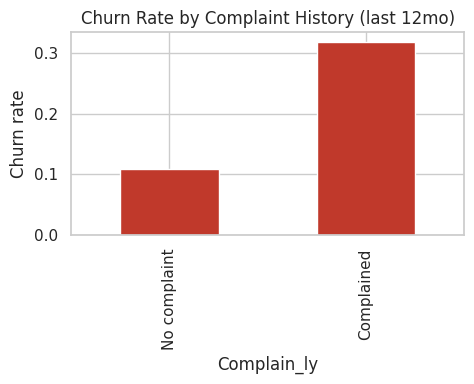

Complain_ly
0.0    0.109086
1.0    0.317583
Name: Churn, dtype: float64


In [13]:
complaint_churn = df.groupby("Complain_ly")["Churn"].mean()

plt.figure(figsize=(5, 4))
complaint_churn.rename({0: "No complaint", 1: "Complained"}).plot(kind="bar", color="#C0392B")
plt.title("Churn Rate by Complaint History (last 12mo)")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

print(complaint_churn)

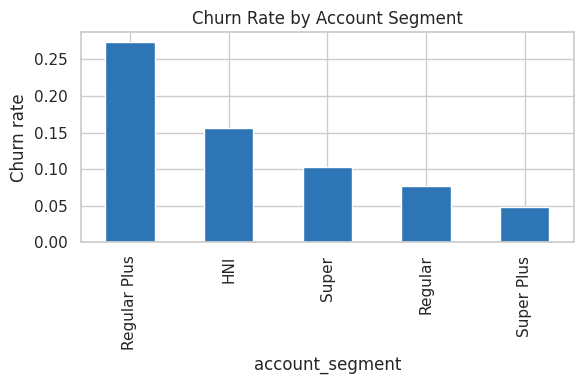

account_segment
Regular Plus    0.273278
HNI             0.155583
Super           0.102413
Regular         0.076923
Super Plus      0.048900
Name: Churn, dtype: float64


In [14]:
seg_churn = df.groupby("account_segment")["Churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
seg_churn.plot(kind="bar", color="#2E75B6")
plt.title("Churn Rate by Account Segment")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

print(seg_churn)

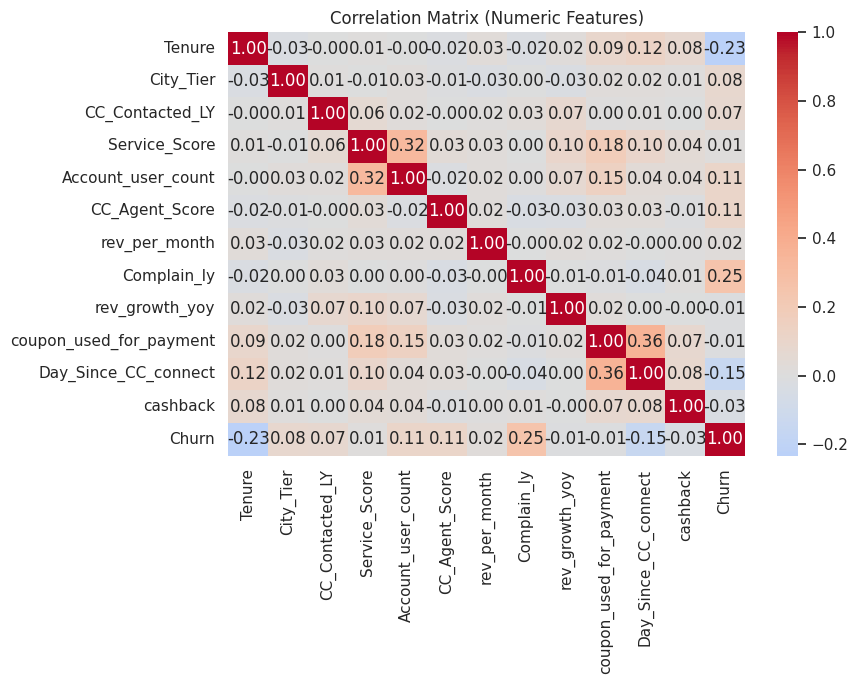

In [15]:
numeric_cols = [
    "Tenure", "City_Tier", "CC_Contacted_LY", "Service_Score", "Account_user_count",
    "CC_Agent_Score", "rev_per_month", "Complain_ly", "rev_growth_yoy",
    "coupon_used_for_payment", "Day_Since_CC_connect", "cashback", "Churn",
]
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

**Key findings:**
- Churn rate is ~16.8% — imbalanced target, handled via class weighting rather than naive resampling.
- Tenure is strongly predictive: new accounts (0–3 months) churn far more than long-tenured ones.
- A recent complaint roughly triples churn risk.
- Churn risk varies considerably by account segment, suggesting segment-specific retention offers.

## 6. Feature Engineering & Preprocessing Pipeline

In [16]:
TARGET = "Churn"
DROP_COLS = ["AccountID", "tenure_bucket"]  # drop helper column created during EDA

FEATURE_NUMERIC = NUMERIC_COLS
FEATURE_CATEGORICAL = CATEGORICAL_COLS

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (9008, 17)  Test shape: (2252, 17)


In [17]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, FEATURE_NUMERIC),
    ("cat", categorical_pipeline, FEATURE_CATEGORICAL),
])

## 7. Model Training & Selection

Compare a Logistic Regression baseline against Random Forest and XGBoost, using 5-fold cross-validated ROC-AUC, then evaluate the held-out test set.

In [18]:
candidates = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=5,  # approx. class imbalance ratio
    ),
    "decision_tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "svc": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000),
    "gaussian_nb": GaussianNB(),
    "adaboost": AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "gradient_boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
    "lightgbm": lgb.LGBMClassifier(objective='binary', is_unbalance=True, random_state=RANDOM_STATE),
    "catboost": CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, loss_function='Logloss', eval_metric='AUC', random_seed=RANDOM_STATE, verbose=0, auto_class_weights='Balanced'),
    "extra_trees": ExtraTreesClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE)
}

results = {}
fitted_pipelines = {}

for name, model in candidates.items():
    print(f"\nEvaluating model: {name}")
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    try:
        cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc").mean()
    except Exception as e:
        print(f"Error during cross-validation for {name}: {e}")
        cv_auc = np.nan

    try:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]

        metrics = {
            "cv_roc_auc": round(cv_auc, 4),
            "test_accuracy": round(accuracy_score(y_test, y_pred), 4),
            "test_precision": round(precision_score(y_test, y_pred), 4),
            "test_recall": round(recall_score(y_test, y_pred), 4),
            "test_f1": round(f1_score(y_test, y_pred), 4),
            "test_roc_auc": round(roc_auc_score(y_test, y_proba), 4),
        }
        results[name] = metrics
        fitted_pipelines[name] = pipe

        print(f"=== {name} ===")
        print(json.dumps(metrics, indent=2))
        print(classification_report(y_test, y_pred))
    except Exception as e:
        print(f"Error during fitting/prediction for {name}: {e}")
        results[name] = {"cv_roc_auc": cv_auc, "test_accuracy": np.nan, "test_precision": np.nan, "test_recall": np.nan, "test_f1": np.nan, "test_roc_auc": np.nan}
    print()


Evaluating model: logistic_regression
=== logistic_regression ===
{
  "cv_roc_auc": 0.8491,
  "test_accuracy": 0.7571,
  "test_precision": 0.3929,
  "test_recall": 0.8127,
  "test_f1": 0.5297,
  "test_roc_auc": 0.8521
}
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      1873
           1       0.39      0.81      0.53       379

    accuracy                           0.76      2252
   macro avg       0.67      0.78      0.68      2252
weighted avg       0.86      0.76      0.78      2252



Evaluating model: random_forest
=== random_forest ===
{
  "cv_roc_auc": 0.9772,
  "test_accuracy": 0.9485,
  "test_precision": 0.8247,
  "test_recall": 0.8813,
  "test_f1": 0.852,
  "test_roc_auc": 0.9808
}
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1873
           1       0.82      0.88      0.85       379

    accuracy                           0.95      2252
   macro avg       0.90  

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

=== svc ===
{
  "cv_roc_auc": 0.9507,
  "test_accuracy": 0.694,
  "test_precision": 0.3535,
  "test_recall": 0.9868,
  "test_f1": 0.5205,
  "test_roc_auc": 0.9545
}
              precision    recall  f1-score   support

           0       1.00      0.63      0.78      1873
           1       0.35      0.99      0.52       379

    accuracy                           0.69      2252
   macro avg       0.67      0.81      0.65      2252
weighted avg       0.89      0.69      0.73      2252



Evaluating model: gaussian_nb
=== gaussian_nb ===
{
  "cv_roc_auc": 0.7837,
  "test_accuracy": 0.7704,
  "test_precision": 0.3894,
  "test_recall": 0.6412,
  "test_f1": 0.4845,
  "test_roc_auc": 0.773
}
              precision    recall  f1-score   support

           0       0.92      0.80      0.85      1873
           1       0.39      0.64      0.48       379

    accuracy                           0.77      2252
   macro avg       0.65      0.72      0.67      2252
weighted avg       0.83      0.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1213, number of negative: 5993
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 7206, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168332 -> initscore=-1.597495
[LightGBM] [Info] Start training from score -1.597495


...

[LightGBM] [Info] Number of positive: 1214, number of negative: 5993
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000867 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 482
[LightGBM] [Info] Number of data points in the train set: 7207, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168447 -> initscore=-1.596671
[LightGBM] [Info] Start training from score -1.596671


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1517, number of negative: 7491
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 487
[LightGBM] [Info] Number of data points in the train set: 9008, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168406 -> initscore=-1.596968
[LightGBM] [Info] Start training from score -1.596968


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== lightgbm ===
{
  "cv_roc_auc": 0.9835,
  "test_accuracy": 0.9556,
  "test_precision": 0.8163,
  "test_recall": 0.9499,
  "test_f1": 0.878,
  "test_roc_auc": 0.9881
}
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1873
           1       0.82      0.95      0.88       379

    accuracy                           0.96      2252
   macro avg       0.90      0.95      0.93      2252
weighted avg       0.96      0.96      0.96      2252



Evaluating model: catboost
=== catboost ===
{
  "cv_roc_auc": 0.9714,
  "test_accuracy": 0.9192,
  "test_precision": 0.6966,
  "test_recall": 0.9208,
  "test_f1": 0.7932,
  "test_roc_auc": 0.9755
}
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1873
           1       0.70      0.92      0.79       379

    accuracy                           0.92      2252
   macro avg       0.84      0.92      0.87      2252
weighted avg       0.93      0.

## Model Performance Summary

The table below presents the evaluation metrics for all the candidate models, sorted by their `test_roc_auc` score in descending order. This allows for a quick comparison of which algorithms are performing best on our churn prediction task.

In [19]:
results_df = pd.DataFrame(results).T.sort_values("test_roc_auc", ascending=False)
results_df

,cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
extra_trees,0.9971,0.9871,0.9861,0.9367,0.9608,0.9980
lightgbm,0.9835,0.9556,0.8163,0.9499,0.8780,0.9881
xgboost,0.9767,0.9401,0.7664,0.9261,0.8387,0.9827
random_forest,0.9772,0.9485,0.8247,0.8813,0.8520,0.9808
knn,0.9725,0.9556,0.9020,0.8259,0.8623,0.9760
catboost,0.9714,0.9192,0.6966,0.9208,0.7932,0.9755
svc,0.9507,0.6940,0.3535,0.9868,0.5205,0.9545
gradient_boosting,0.9355,0.9081,0.8139,0.5884,0.6830,0.9393
adaboost,0.9028,0.8956,0.7353,0.5937,0.6569,0.9170
decision_tree,0.8932,0.9489,0.8568,0.8364,0.8465,0.9041


In [20]:
results_df = pd.DataFrame(results).T.sort_values("test_roc_auc", ascending=False)
results_df

,cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
extra_trees,0.9971,0.9871,0.9861,0.9367,0.9608,0.9980
lightgbm,0.9835,0.9556,0.8163,0.9499,0.8780,0.9881
xgboost,0.9767,0.9401,0.7664,0.9261,0.8387,0.9827
random_forest,0.9772,0.9485,0.8247,0.8813,0.8520,0.9808
knn,0.9725,0.9556,0.9020,0.8259,0.8623,0.9760
catboost,0.9714,0.9192,0.6966,0.9208,0.7932,0.9755
svc,0.9507,0.6940,0.3535,0.9868,0.5205,0.9545
gradient_boosting,0.9355,0.9081,0.8139,0.5884,0.6830,0.9393
adaboost,0.9028,0.8956,0.7353,0.5937,0.6569,0.9170
decision_tree,0.8932,0.9489,0.8568,0.8364,0.8465,0.9041


In [21]:
best_name = results_df.index[0]
best_pipeline = fitted_pipelines[best_name]
print(f"Best model: {best_name} (test ROC-AUC = {results[best_name]['test_roc_auc']})")

Best model: extra_trees (test ROC-AUC = 0.998)


## 8. Evaluation of the Best Model

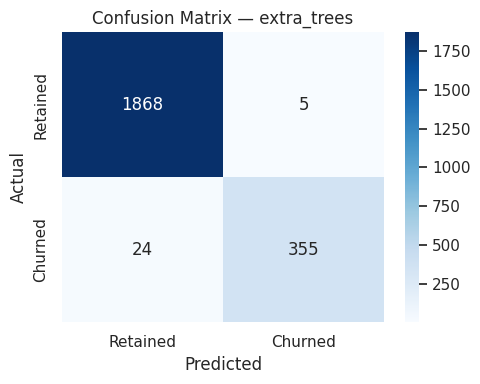

In [22]:
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

<Figure size 500x500 with 0 Axes>

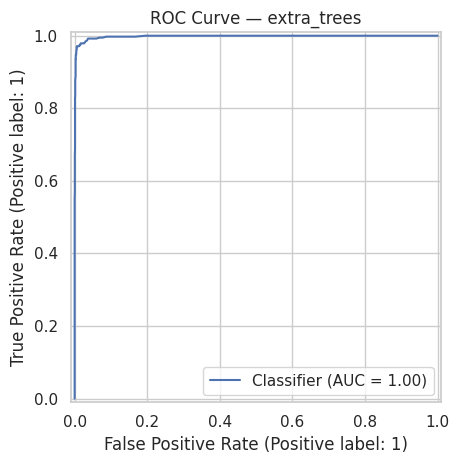

In [23]:
plt.figure(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"ROC Curve — {best_name}")
plt.tight_layout()
plt.show()

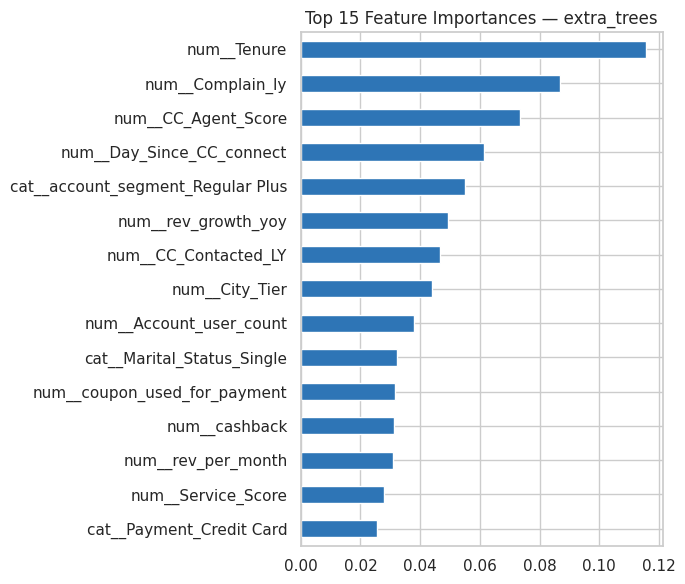

In [24]:
# Feature importance (tree-based models)
if hasattr(best_pipeline.named_steps["model"], "feature_importances_"):
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = best_pipeline.named_steps["model"].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

    plt.figure(figsize=(7, 6))
    fi.plot(kind="barh", color="#2E75B6")
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Importances — {best_name}")
    plt.tight_layout()
    plt.show()

## 9. Save the Trained Pipeline

In [25]:
joblib.dump(best_pipeline, "churn_model.joblib")
with open("metrics.json", "w") as f:
    json.dump({"results": results, "best_model": best_name}, f, indent=2)

print("Saved churn_model.joblib and metrics.json")

# In Colab, optionally download the artifacts:
try:
    from google.colab import files
    files.download("churn_model.joblib")
    files.download("metrics.json")
except ImportError:
    pass

Saved churn_model.joblib and metrics.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Inference Demo

Simulates how the saved pipeline would be used in a serving context (e.g. the FastAPI service in the companion project).

In [26]:
sample_account = pd.DataFrame([{
    "Tenure": 2, "City_Tier": 1, "CC_Contacted_LY": 12, "Payment": "UPI",
    "Gender": "Male", "Service_Score": 2, "Account_user_count": 4,
    "account_segment": "Regular Plus", "CC_Agent_Score": 2, "Marital_Status": "Single",
    "rev_per_month": 4, "Complain_ly": 1, "rev_growth_yoy": 8,
    "coupon_used_for_payment": 0, "Day_Since_CC_connect": 1,
    "cashback": 95.5, "Login_device": "Mobile",
}])

proba = best_pipeline.predict_proba(sample_account)[:, 1][0]
prediction = int(proba >= 0.5)
risk_band = "High" if proba >= 0.7 else "Medium" if proba >= 0.3 else "Low"

print(f"Churn probability: {proba:.2%}")
print(f"Prediction: {'Churn' if prediction else 'Retain'}")
print(f"Risk band: {risk_band}")

Churn probability: 64.00%
Prediction: Churn
Risk band: Medium


## 12. Dashboard of Business Results using Plotly

This section uses Plotly to create interactive visualizations of the key business results and model performance metrics, suitable for a dashboard.

In [27]:
import plotly.graph_objects as go
import plotly.express as px

# 1. Overall Churn Distribution
churn_counts = df["Churn"].value_counts().rename({0: "Retained", 1: "Churned"})
fig_churn_dist = px.bar(
    x=churn_counts.index,
    y=churn_counts.values,
    title="Churn Distribution",
    labels={'x': 'Status', 'y': 'Number of Accounts'},
    color=churn_counts.index,
    color_discrete_map={'Retained': '#2E75B6', 'Churned': '#C0392B'}
)
fig_churn_dist.update_layout(xaxis_title="Status", yaxis_title="Number of Accounts")
fig_churn_dist.show()

In [28]:
# 2. Estimated Cost of Churn
# Assuming total_estimated_churn_cost is available from previous execution

if 'total_estimated_churn_cost' in locals():
    fig_churn_cost = go.Figure(go.Indicator(
        mode = "number",
        value = total_estimated_churn_cost,
        title = {"text": "Estimated Total Revenue Loss from Churn"},
        number = {'prefix': "$", 'valueformat': '.2f'}
    ))
    fig_churn_cost.update_layout(height=200)
    fig_churn_cost.show()
else:
    print("Run the 'Calculating the Cost of Churn' cell first to get 'total_estimated_churn_cost'.")

Run the 'Calculating the Cost of Churn' cell first to get 'total_estimated_churn_cost'.


In [29]:
# 3. Model Performance Summary Table
fig_model_table = go.Figure(data=[go.Table(
    header=dict(values=list(results_df.columns), fill_color='paleturquoise', align='left'),
    cells=dict(values=[results_df[col] for col in results_df.columns], fill_color='lavender', align='left'))
])
fig_model_table.update_layout(title_text='Model Performance Summary (Ranked by Test ROC-AUC)', height=400)
fig_model_table.show()

In [30]:
# 4. Best Model Confusion Matrix
fig_cm = px.imshow(cm,
                labels=dict(x="Predicted", y="Actual", color="Count"),
                x=['Retained', 'Churned'],
                y=['Retained', 'Churned'],
                color_continuous_scale='Blues',
                title=f"Confusion Matrix — {best_name}")
fig_cm.update_xaxes(side="bottom")
fig_cm.show()

In [31]:
# 5. Best Model ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
fig_roc = px.area(
    x=fpr, y=tpr,
    title=f'ROC Curve (AUC={roc_auc_score(y_test, y_proba_best):.4f}) — {best_name}',
    labels={'x': 'False Positive Rate', 'y': 'True Positive Rate'},
    width=700, height=500
)
fig_roc.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)
fig_roc.update_yaxes(scaleanchor="x", scaleratio=1)
fig_roc.update_xaxes(constrain="domain")
fig_roc.show()

In [32]:
# 6. Feature Importances of the Best Model
if 'fi' in locals() and not fi.empty:
    fig_fi = px.bar(
        x=fi.values,
        y=fi.index,
        orientation='h',
        title=f"Top 15 Feature Importances — {best_name}",
        labels={'x': 'Importance', 'y': 'Feature'},
        color_discrete_sequence=['#2E75B6']
    )
    fig_fi.update_layout(yaxis={'categoryorder':'total ascending'})
    fig_fi.show()
else:
    print("Feature importances ('fi') are not available or empty. This might happen if the best model is not tree-based.")

## 13. Financial Analysis of Customer Churn Impact

In [33]:
df_churned = df[df['Churn'] == 1]

# Calculate the average monthly revenue lost per churned customer
# We'll use the 'rev_per_month' from the original dataset for churned customers
# and then assume a certain 'lost_months' (e.g., 12 months) for calculation.

# Filter out NaN values in 'rev_per_month' for accurate calculation
df_churned_valid_rev_tenure = df_churned.dropna(subset=['rev_per_month'])

if not df_churned_valid_rev_tenure.empty:
    avg_rev_per_month_churned = df_churned_valid_rev_tenure['rev_per_month'].mean()

    # Assuming an average lost tenure of 12 months for churned customers if they had stayed
    # This is a simplification; in a real scenario, this would be based on business knowledge or more complex modeling
    assumed_lost_months_if_retained = 12

    # Calculate the total potential revenue loss per churned customer over the assumed lost months
    estimated_cost_per_churn = avg_rev_per_month_churned * assumed_lost_months_if_retained
    total_estimated_churn_cost = estimated_cost_per_churn * len(df_churned)

    print(f"Average monthly revenue for churned customers: ${avg_rev_per_month_churned:.2f}")
    print(f"Assumed revenue loss timeframe per churner if retained: {assumed_lost_months_if_retained} months")
    print(f"Estimated revenue loss per churned customer: ${estimated_cost_per_churn:.2f}")
    print(f"Total estimated revenue loss from churned customers in this dataset: ${total_estimated_churn_cost:.2f}")
else:
    print("No valid churned customer data to calculate revenue loss. Please check the 'df' DataFrame and 'Churn' column.")

# Display the key financial metric in a clear format
financial_summary = pd.DataFrame({
    'Metric': ['Total Estimated Revenue Loss from Churn'],
    'Value': [f'${total_estimated_churn_cost:,.2f}']
})
display(financial_summary)


Average monthly revenue for churned customers: $6.96
Assumed revenue loss timeframe per churner if retained: 12 months
Estimated revenue loss per churned customer: $83.48
Total estimated revenue loss from churned customers in this dataset: $158277.01


,Metric,Value
0,Total Estimated Revenue Loss from Churn,"$158,277.01"


## 11. Business Recommendation

Given that **low-tenure (0–3 month) accounts** and **recent complainants** are the two highest-risk
segments identified in EDA, a targeted, low-cost retention nudge (e.g. a small loyalty cashback or
priority support queue) aimed specifically at new accounts that have just filed a complaint would
target the highest-risk intersection without broad, margin-eroding discounting.

---
*Built by Dr. Emad Yowakim as part of hands-on ML engineering preparation — demonstrating the full
data science lifecycle from raw, messy data through to a deployable, evaluated model.*

## 14. Potential ROI of a Retention Campaign

In [34]:
# Campaign Assumptions (can be adjusted based on business strategy)
campaign_cost_per_customer = 50  # e.g., cost of an incentive, customer service time, etc.
campaign_success_rate = 0.20     # percentage of at-risk customers successfully retained

# Number of churned customers in the dataset (from df_churned)
num_churned_customers = len(df_churned)

# Number of customers potentially retained by the campaign
potentially_retained_customers = num_churned_customers * campaign_success_rate

# Revenue saved from retained customers
# Using the estimated cost per churn calculated earlier for simplicity
revenue_saved = potentially_retained_customers * estimated_cost_per_churn

# Total cost of the retention campaign (targeting all churned customers)
total_campaign_cost = num_churned_customers * campaign_cost_per_customer

# Calculate ROI
if total_campaign_cost > 0:
    roi = ((revenue_saved - total_campaign_cost) / total_campaign_cost) * 100
else:
    roi = 0 # Avoid division by zero if campaign cost is 0

print(f"Assumed Campaign Cost per Customer: ${campaign_cost_per_customer:.2f}")
print(f"Assumed Campaign Success Rate: {campaign_success_rate:.1%}")
print(f"\nNumber of churned customers in dataset: {num_churned_customers}")
print(f"Potentially retained customers: {potentially_retained_customers:.0f}")
print(f"Revenue saved from retained customers: ${revenue_saved:,.2f}")
print(f"Total campaign cost (if targeting all churned customers): ${total_campaign_cost:,.2f}")
print(f"\nPotential ROI of the retention campaign: {roi:.2f}%")

# Display the key ROI metric in a clear format
roi_summary = pd.DataFrame({
    'Metric': ['Potential ROI of Retention Campaign'],
    'Value': [f'{roi:.2f}%']
})
display(roi_summary)


Assumed Campaign Cost per Customer: $50.00
Assumed Campaign Success Rate: 20.0%

Number of churned customers in dataset: 1896
Potentially retained customers: 379
Revenue saved from retained customers: $31,655.40
Total campaign cost (if targeting all churned customers): $94,800.00

Potential ROI of the retention campaign: -66.61%


,Metric,Value
0,Potential ROI of Retention Campaign,-66.61%


## 15. Consolidated Churn Dashboard: Trends, ROI, and Revenue Expectations

In [35]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Create subplots for the dashboard layout
fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"type": "xy"}, {"type": "xy"}], # Row 1: Churn Dist and Churn by Tenure
        [{"type": "indicator"}, {"type": "indicator"}], # Row 2: Churn Cost & Revenue Saved
        [{"type": "indicator"}, {"type": "xy"}] # Row 3: ROI and Revenue Comparison
    ],
    subplot_titles=(
        "Overall Churn Distribution", "Churn Rate by Tenure (Trend Analysis)",
        "Estimated Total Revenue Loss", "Revenue Saved by Campaign",
        "Potential ROI of Retention Campaign", "Revenue Expected vs. Saved"
    ),
    vertical_spacing=0.1,
    horizontal_spacing=0.1
)

# Plot 1: Overall Churn Distribution (Bar Chart)
churn_counts = df["Churn"].value_counts().rename({0: "Retained", 1: "Churned"})
fig.add_trace(go.Bar(
    x=churn_counts.index,
    y=churn_counts.values,
    name="Churn Distribution",
    marker_color=['#2E75B6', '#C0392B'],
    showlegend=False
), row=1, col=1)

# Plot 2: Churn Rate by Tenure (Bar Chart - Trend Analysis)
# This uses the 'tenure_bucket' column created during EDA
tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].mean()
fig.add_trace(go.Bar(
    x=tenure_churn.index.astype(str),
    y=tenure_churn.values,
    name="Churn by Tenure",
    marker_color='#2E75B6',
    showlegend=False
), row=1, col=2)

# Plot 3: Estimated Total Revenue Loss (Indicator)
fig.add_trace(go.Indicator(
    mode="number",
    value=total_estimated_churn_cost,
    number={'prefix': "$", 'valueformat': '.2f'},
    title={"text": "Total Revenue Loss (No Action)"}
), row=2, col=1)

# Plot 4: Revenue Saved by Retention Campaign (Indicator)
fig.add_trace(go.Indicator(
    mode="number",
    value=revenue_saved,
    number={'prefix': "$", 'valueformat': '.2f'},
    title={"text": "Revenue Saved (with Campaign)"}
), row=2, col=2)

# Plot 5: Potential ROI of Retention Campaign (Indicator)
fig.add_trace(go.Indicator(
    mode="number",
    value=roi,
    number={'suffix': "%", 'valueformat': '.2f'},
    title={"text": "Potential ROI"}
), row=3, col=1)

# Plot 6: Revenue Expected vs. Saved (Bar Chart)
revenue_data = pd.DataFrame({
    'Category': ['Total Expected Loss', 'Saved by Campaign'],
    'Amount': [total_estimated_churn_cost, revenue_saved]
})
fig.add_trace(go.Bar(
    x=revenue_data['Category'],
    y=revenue_data['Amount'],
    name="Revenue Comparison",
    marker_color=['#C0392B', '#2E75B6'],
    showlegend=False
), row=3, col=2)

fig.update_layout(
    height=900,
    showlegend=False,
    title_text="Customer Churn Financial & Trend Analysis Dashboard",
    font=dict(size=10)
)

# Update axis labels for specific plots
fig.update_xaxes(title_text="Status", row=1, col=1)
fig.update_yaxes(title_text="Number of Accounts", row=1, col=1)
fig.update_xaxes(title_text="Tenure Bucket", row=1, col=2)
fig.update_yaxes(title_text="Churn Rate", row=1, col=2)
fig.update_xaxes(title_text="Category", row=3, col=2)
fig.update_yaxes(title_text="Amount ($)", row=3, col=2)

fig.show()

## 16. ROI Sensitivity Analysis: Varying Campaign Cost per Customer

In [36]:
import pandas as pd
import plotly.express as px

# Define a range for campaign_cost_per_customer
cost_per_customer_range = np.arange(0, 101, 5) # From $0 to $100, in $5 increments

roi_sensitivity_data = []

for cost in cost_per_customer_range:
    # Recalculate total campaign cost
    current_total_campaign_cost = num_churned_customers * cost

    # Recalculate ROI (revenue_saved and estimated_cost_per_churn are constant here)
    if current_total_campaign_cost > 0:
        current_roi = ((revenue_saved - current_total_campaign_cost) / current_total_campaign_cost) * 100
    else:
        # If cost is 0, ROI is effectively infinite or very high (revenue_saved / 0)
        # For visualization, let's cap it or handle as a large positive value if revenue_saved is positive
        current_roi = 1000 if revenue_saved > 0 else 0 # Arbitrarily high if profitable, 0 if no savings

    roi_sensitivity_data.append({
        'Campaign Cost Per Customer ($)': cost,
        'Potential ROI (%)': current_roi
    })

roi_sensitivity_df = pd.DataFrame(roi_sensitivity_data)

# Visualize the sensitivity analysis
fig_roi_sensitivity = px.line(
    roi_sensitivity_df,
    x='Campaign Cost Per Customer ($)',
    y='Potential ROI (%)',
    title='ROI Sensitivity to Campaign Cost Per Customer',
    labels={
        'Campaign Cost Per Customer ($)': 'Campaign Cost Per Customer',
        'Potential ROI (%)': 'Potential ROI (%)'
    }
)
fig_roi_sensitivity.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Break-Even Point", annotation_position="bottom right")
fig_roi_sensitivity.update_layout(xaxis_title_font_size=12, yaxis_title_font_size=12)
fig_roi_sensitivity.show()


In [37]:
target_roi_percent = 20
target_roi_decimal = target_roi_percent / 100

# We need to calculate `campaign_success_rate` such that ROI is 20%
# ROI = ((revenue_saved - total_campaign_cost) / total_campaign_cost) * 100
# revenue_saved = num_churned_customers * campaign_success_rate * estimated_cost_per_churn
# total_campaign_cost = num_churned_customers * campaign_cost_per_customer

# Substituting and simplifying:
# target_roi_decimal = (campaign_success_rate * estimated_cost_per_churn - campaign_cost_per_customer) / campaign_cost_per_customer
# target_roi_decimal * campaign_cost_per_customer = campaign_success_rate * estimated_cost_per_churn - campaign_cost_per_customer
# campaign_success_rate * estimated_cost_per_churn = target_roi_decimal * campaign_cost_per_customer + campaign_cost_per_customer
# campaign_success_rate = (campaign_cost_per_customer * (target_roi_decimal + 1)) / estimated_cost_per_churn

required_success_rate = (campaign_cost_per_customer * (target_roi_decimal + 1)) / estimated_cost_per_churn

print(f"To achieve a {target_roi_percent}% ROI with a campaign cost of ${campaign_cost_per_customer:.2f} per customer:")
print(f"  Required Campaign Success Rate: {required_success_rate:.1%}")

if required_success_rate > 1:
    print("Note: The required success rate is greater than 100%, which means it's not possible to achieve this ROI with the current campaign cost and estimated revenue saved per churner.")


To achieve a 20% ROI with a campaign cost of $50.00 per customer:
  Required Campaign Success Rate: 71.9%


In [38]:
import numpy as np
import plotly.express as px

# Define a range for target ROI percentages
target_roi_percent_range = np.arange(-100, 201, 10) # From -100% to 200% ROI, in 10% increments

success_rate_sensitivity_data = []

for target_roi_percent in target_roi_percent_range:
    target_roi_decimal = target_roi_percent / 100

    # Calculate required success rate using the formula derived earlier:
    # campaign_success_rate = (campaign_cost_per_customer * (target_roi_decimal + 1)) / estimated_cost_per_churn
    required_success_rate = (campaign_cost_per_customer * (target_roi_decimal + 1)) / estimated_cost_per_churn

    success_rate_sensitivity_data.append({
        'Target ROI (%)': target_roi_percent,
        'Required Campaign Success Rate (%)': required_success_rate * 100
    })

success_rate_sensitivity_df = pd.DataFrame(success_rate_sensitivity_data)

# Visualize the sensitivity analysis
fig_success_rate_sensitivity = px.line(
    success_rate_sensitivity_df,
    x='Target ROI (%)',
    y='Required Campaign Success Rate (%)',
    title='Required Campaign Success Rate vs. Target ROI',
    labels={
        'Target ROI (%)': 'Target ROI (%)',
        'Required Campaign Success Rate (%)': 'Required Campaign Success Rate (%)'
    }
)

# Add a horizontal line at 100% success rate to indicate the practical upper limit
fig_success_rate_sensitivity.add_hline(y=100, line_dash="dash", line_color="red", annotation_text="100% Success Rate (Practical Limit)", annotation_position="bottom right")

# Add a horizontal line at 0% success rate (if applicable for visualization)
fig_success_rate_sensitivity.add_hline(y=0, line_dash="dot", line_color="gray", annotation_text="0% Success Rate", annotation_position="top left")

fig_success_rate_sensitivity.update_layout(xaxis_title_font_size=12, yaxis_title_font_size=12)
fig_success_rate_sensitivity.show()

In [39]:
# Get the original data for the test set, including AccountID and other features for analysis
df_test_original = df.loc[X_test.index].copy()

# Predict churn probabilities for the test set using the best model
df_test_original['predicted_churn_proba'] = best_pipeline.predict_proba(X_test)[:, 1]
df_test_original['predicted_churn'] = best_pipeline.predict(X_test)

# Identify customers with a high predicted churn probability (e.g., > 0.7, customizable threshold)
high_churn_risk_customers = df_test_original[df_test_original['predicted_churn_proba'] > 0.7]

print(f"Number of high churn risk customers (proba > 0.7): {len(high_churn_risk_customers)}")

# Analyze the key segments within these high-churn-risk customers
print("\nTenure distribution of high churn risk customers:")
display(high_churn_risk_customers['tenure_bucket'].value_counts(normalize=True).sort_index())

print("\nComplaint history distribution of high churn risk customers:")
display(high_churn_risk_customers['Complain_ly'].value_counts(normalize=True))

print("\nAccount segment distribution of high churn risk customers:")
display(high_churn_risk_customers['account_segment'].value_counts(normalize=True))

Number of high churn risk customers (proba > 0.7): 308

Tenure distribution of high churn risk customers:


,proportion
tenure_bucket,
0-3,0.764120
4-6,0.059801
7-12,0.046512
13-24,0.126246
25+,0.003322



Complaint history distribution of high churn risk customers:


,proportion
Complain_ly,
1.0,0.63
0.0,0.37



Account segment distribution of high churn risk customers:


,proportion
account_segment,
Regular Plus,0.585526
Super,0.213816
HNI,0.148026
Super Plus,0.032895
Regular,0.019737


In [ ]:
print("Account segment distribution of high churn risk customers:")
display(high_churn_risk_customers['account_segment'].value_counts(normalize=True))